# Screening the synthetic targets

Experiments 1–3 reproduced the reference work's gait-phase ensemble, autoencoder and GAN. The
remaining architecture is the ensemble again, trained against a target computed from the input
window itself rather than against gait phase — which matters beyond completing the table,
because **gait phase is not available at run time.** It is recovered from force-plate data
offline, so the reference work can only ever measure branch *disagreement*. A target computable
from the sixteen sensor channels is available live, and that unlocks measuring prediction
*error* online as a second, independent axis.

This notebook screens three candidate targets **before** committing compute to them. Three full
two-stage protocols is roughly twenty-four hours, and a target with the wrong properties
produces a near-zero variance signal at the end of it.

### What we are screening for, and why

Each criterion is a lesson already paid for in this project:

1. **Scale invariance.** The GAN's uncertainty score turned out to be a monotone function of
   window amplitude (rank correlation −0.86) and was beaten by raw amplitude used alone
   (AUROC 0.807 against 0.727). Any target that is largely a measure of how loud the window is
   will reproduce that failure.
2. **Conditioning.** A target that is numerically undefined on some tasks asks the network to
   predict a coin flip. Standing is the danger case: it is nearly motionless.
3. **Difficulty.** Ensemble disagreement is driven by how hard the target is. If a two-tap
   linear filter solves it, all seven branches learn the same function and agree everywhere —
   including out-of-distribution — and the variance carries no information. This is the
   likeliest explanation for why the reference work's synthetic-target ensemble reached F1 62.5
   against the gait-phase ensemble's 90.3.

### The candidates

| # | target | outputs | computable live? |
|---|---|---|---|
| A | summed pairwise channel correlation | 1 | yes |
| B | hip angle, both legs, `h` samples ahead | 2 | yes |
| C | all sixteen channels, `h` samples ahead | 16 | yes |

Target A is the reference work's own choice and reproduces its Table I row. B and C differ only
in output width, deliberately: run at the same horizon they form a clean ablation on whether
predicting the whole sensor state helps or hurts.

Target definitions are imported from `ml/vanilla/targets.py` rather than written here, so the
target this notebook clears is bit-identical to the one the models will train against.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score


def find_repo_root(marker: str = "data/processed") -> Path:
    for d in [Path.cwd(), *Path.cwd().parents]:
        if (d / marker).is_dir():
            return d
    raise FileNotFoundError(marker)


REPO = find_repo_root()
sys.path.insert(0, str(REPO / "ml" / "vanilla"))     # one definition of every target

from dataset import AutoencoderData                                      # noqa: E402
from targets import (ANGLE_CHANNELS, DEFAULT_HORIZON, MIN_SD, STRIDE,    # noqa: E402
                     channel_indices, correlation_matrix, degenerate_fraction,
                     forecast_rows, forecast_skill, summed_pairwise_corr)

MODE_NAMES = {"LG": "level ground", "RA": "ramp ascent", "RD": "ramp descent",
              "SA": "stair ascent", "SD": "stair descent", "ST": "standing",
              "TR": "transitions"}
MODE_COLS = {"LG": "#4C72B0", "RA": "#6FA8DC", "RD": "#9FC5E8",
             "SA": "#C44E52", "SD": "#DD8452", "ST": "#55A868", "TR": "#8172B3"}
ORDER = ("LG", "RA", "RD", "SA", "SD", "TR", "ST")
C_ID, C_OOD = "#4C72B0", "#DD8452"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

data = AutoencoderData(batch_size=1024)
CH = data.channels
print(data)
print(f"channels: {CH}")

AutoencoderData(train=187,993, val=64,350, test=61,956, ood_val=23,344, ood_test=23,043, shape=(16, 200))
channels: ['thigh_accel_x_l', 'thigh_accel_y_l', 'thigh_accel_z_l', 'thigh_gyro_x_l', 'thigh_gyro_y_l', 'thigh_gyro_z_l', 'enc_angle_l', 'enc_velo_l', 'thigh_accel_x_r', 'thigh_accel_y_r', 'thigh_accel_z_r', 'thigh_gyro_x_r', 'thigh_gyro_y_r', 'thigh_gyro_z_r', 'enc_angle_r', 'enc_velo_r']


### Sample

A stratified sample rather than every window: 20,000 in-distribution and 20,000 held-out
windows is far more than enough to characterise a target's distribution, and it keeps every
cell below interactive. The held-out (OOD) windows are included because a target's behaviour on
the tasks we intend to *detect* is exactly what is at issue — particularly standing, which is
the numerically hostile case.

In [2]:
rng = np.random.default_rng(0)
N_EACH = 20_000


def sample(split, n):
    sp = data.splits[split] if isinstance(split, str) else split
    idx = np.sort(rng.choice(len(sp), min(n, len(sp)), replace=False))
    return sp.tensors(idx).numpy(), sp.meta.iloc[idx].reset_index(drop=True)


Xi, mi = sample("test", N_EACH)
Xo, mo = sample(data.ood["test"], N_EACH)
mi = mi.assign(kind="ID")
mo = mo.assign(kind="OOD")

X = np.concatenate([Xi, Xo])
meta = pd.concat([mi, mo], ignore_index=True)
y = np.r_[np.zeros(len(Xi), int), np.ones(len(Xo), int)]

# amplitude: the mean across channels of each window's standard deviation, standardized units.
# This is the quantity the GAN's score collapsed to, so it is the yardstick for criterion 1.
amp = X.std(axis=2).mean(axis=1)

print(f"{len(Xi):,} ID + {len(Xo):,} OOD = {len(X):,} windows, shape {X.shape[1:]}")
print(meta.groupby(["kind", "mode"], observed=True).size().to_string())

20,000 ID + 20,000 OOD = 40,000 windows, shape (16, 200)
kind  mode
ID    LG      9267
      RA      5973
      RD      4760
OOD   SA      8913
      SD      8824
      ST       546
      TR      1717


---
## Part 1 — Target A: summed pairwise correlation

The reference work's choice. For each window, compute the Pearson correlation between every
pair of the sixteen channels and sum the 120 values. The network is being asked to predict the
instantaneous *coupling structure* of the sensor suite.

Two things recommend it. It needs no labels at all, and Pearson correlation divides out each
channel's standard deviation, so it is **scale-invariant by construction** — the one candidate
here that structurally cannot repeat the GAN's amplitude failure.

### 1.1 What the target is made of

Before summarising 120 numbers into one, look at them. Two correlation matrices: a level-ground
window and a standing window.

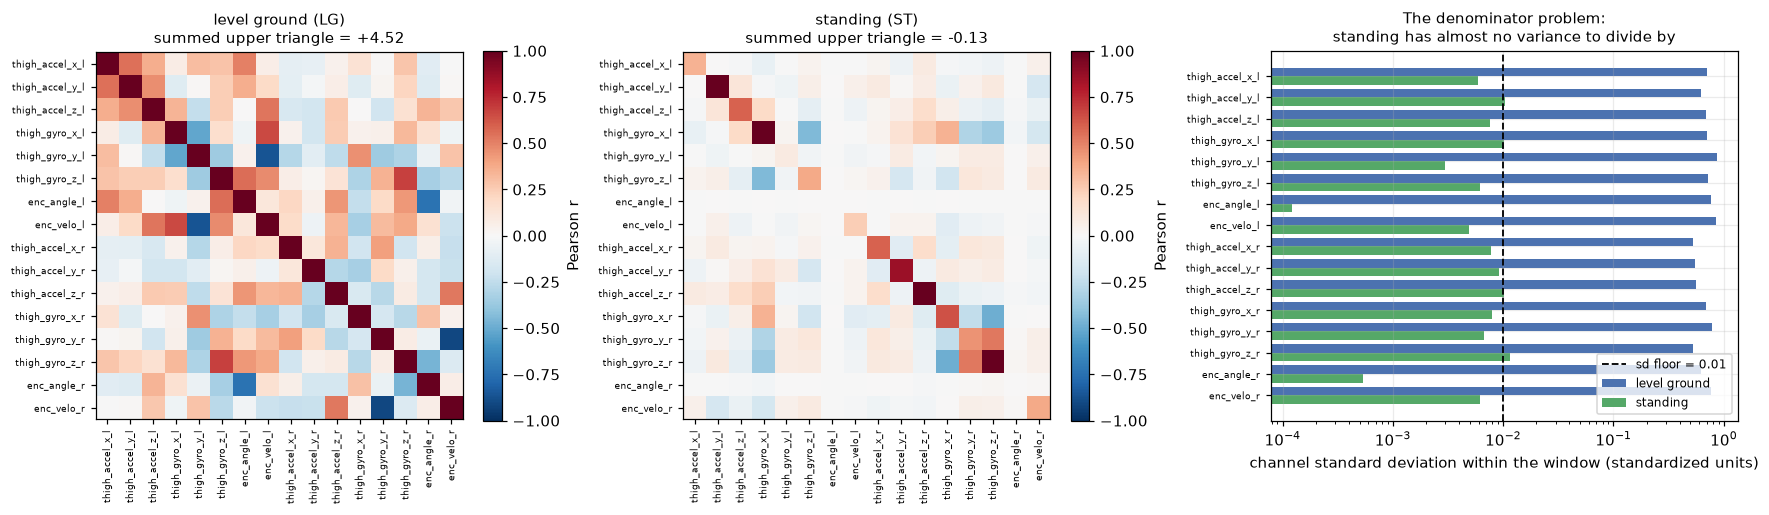

In [3]:
def pick(mode, kind=None):
    sel = (meta["mode"] == mode).to_numpy()
    return int(np.flatnonzero(sel)[0])


i_lg, i_st = pick("LG"), pick("ST")
R = correlation_matrix(X[[i_lg, i_st]])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6),
                         gridspec_kw={"width_ratios": [1, 1, 1.15]})
for ax, r, (mo, idx) in zip(axes[:2], R, (("LG", i_lg), ("ST", i_st))):
    im = ax.imshow(r, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(16)); ax.set_yticks(range(16))
    ax.set_xticklabels(CH, rotation=90, fontsize=6)
    ax.set_yticklabels(CH, fontsize=6)
    ax.set_title(f"{MODE_NAMES[mo]} ({mo})\nsummed upper triangle = "
                 f"{summed_pairwise_corr(X[[idx]])[0]:+.2f}", fontsize=10)
    ax.grid(False)
    plt.colorbar(im, ax=ax, fraction=0.046, label="Pearson r")

# per-channel standard deviation: the denominator that makes standing hazardous
w = 0.4
yy = np.arange(16)
axes[2].barh(yy - w/2, (X[i_lg] - X[i_lg].mean(1, keepdims=True)).std(1), w,
             color=MODE_COLS["LG"], label="level ground")
axes[2].barh(yy + w/2, (X[i_st] - X[i_st].mean(1, keepdims=True)).std(1), w,
             color=MODE_COLS["ST"], label="standing")
axes[2].axvline(MIN_SD, color="k", ls="--", lw=1.2, label=f"sd floor = {MIN_SD}")
axes[2].set_xscale("log")
axes[2].set_yticks(yy); axes[2].set_yticklabels(CH, fontsize=6)
axes[2].invert_yaxis()
axes[2].set_xlabel("channel standard deviation within the window (standardized units)")
axes[2].set_title("The denominator problem:\nstanding has almost no variance to divide by",
                  fontsize=10)
axes[2].legend(fontsize=8)
fig.tight_layout()
plt.show()

The left panel is structured: legs are correlated with each other, accelerometer axes cluster,
the encoder channels couple to the sagittal gyro. That structure is what a network could learn.

The right panel is the problem. Standing's channel standard deviations sit two to three orders
of magnitude below level ground's, several of them below the floor drawn on the plot. Pearson
correlation divides by the product of two such numbers, so for standing the "correlation" is
computed between two channels of sensor noise — a different random value every window.

### 1.2 Conditioning, and the fix

`targets.py` floors the standard deviation in the denominator rather than dropping degenerate
pairs. Flooring shrinks such pairs smoothly toward zero instead of introducing a discontinuity,
and zero is the honest value for a constant signal: it has no linear relationship with
anything. Dropping pairs and rescaling by the survivor count does the opposite — standing
retains only about one valid pair in 120, so rescaling would amplify that single noisy value by
a factor of 120.

The question is whether the floor is doing real work, and whether it disturbs the tasks that
were fine already.

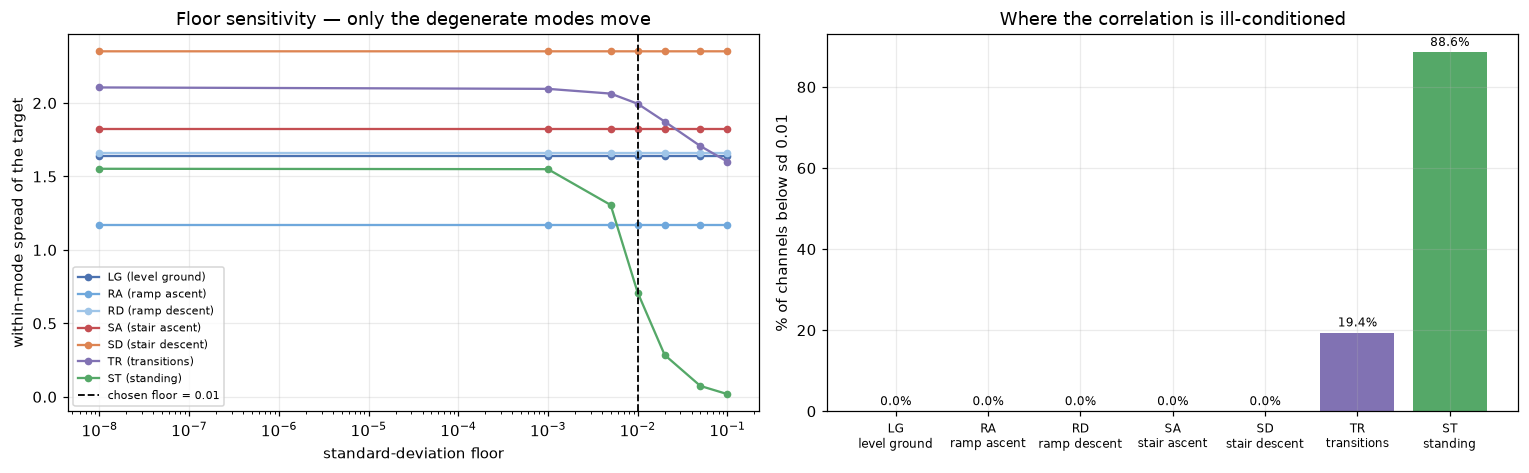

floor  1.000000e-08  1.000000e-03  5.000000e-03  1.000000e-02  2.000000e-02  5.000000e-02  1.000000e-01
mode                                                                                                   
LG             1.64          1.64          1.64          1.64          1.64          1.64          1.64
RA             1.17          1.17          1.17          1.17          1.17          1.17          1.17
RD             1.66          1.66          1.66          1.66          1.66          1.66          1.66
SA             1.82          1.82          1.82          1.82          1.82          1.82          1.82
SD             2.35          2.35          2.35          2.35          2.35          2.35          2.35
TR             2.11          2.10          2.06          2.00          1.87          1.71          1.60
ST             1.55          1.55          1.31          0.71          0.29          0.07          0.02


In [4]:
floors = [1e-8, 0.001, 0.005, 0.01, 0.02, 0.05, 0.1]
rows = []
for mo in ORDER:
    s = (meta["mode"] == mo).to_numpy()
    if not s.any():
        continue
    for f in floors:
        t = summed_pairwise_corr(X[s], min_sd=f)
        rows.append({"mode": mo, "floor": f, "sd": t.std(), "median": np.median(t),
                     "deg": degenerate_fraction(X[s], f).mean()})
sens = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
for mo in ORDER:
    d = sens[sens["mode"] == mo]
    if d.empty:
        continue
    axes[0].plot(d["floor"], d["sd"], "o-", ms=4, color=MODE_COLS[mo],
                 label=f"{mo} ({MODE_NAMES[mo]})")
axes[0].axvline(MIN_SD, color="k", ls="--", lw=1.2, label=f"chosen floor = {MIN_SD}")
axes[0].set_xscale("log")
axes[0].set_xlabel("standard-deviation floor")
axes[0].set_ylabel("within-mode spread of the target")
axes[0].set_title("Floor sensitivity — only the degenerate modes move")
axes[0].legend(fontsize=7)

deg = meta.assign(deg=degenerate_fraction(X)).groupby("mode", observed=True)["deg"].mean()
deg = deg.reindex([m for m in ORDER if m in deg.index])
axes[1].bar(range(len(deg)), 100 * deg.to_numpy(),
            color=[MODE_COLS[m] for m in deg.index])
for i, v in enumerate(100 * deg.to_numpy()):
    axes[1].text(i, v + 1.5, f"{v:.1f}%", ha="center", fontsize=8)
axes[1].set_xticks(range(len(deg)))
axes[1].set_xticklabels([f"{m}\n{MODE_NAMES[m]}" for m in deg.index], fontsize=8)
axes[1].set_ylabel(f"% of channels below sd {MIN_SD}")
axes[1].set_title("Where the correlation is ill-conditioned")
fig.tight_layout()
plt.show()

print(sens.pivot(index="mode", columns="floor", values="sd")
          .reindex([m for m in ORDER if m in sens["mode"].values])
          .round(2).to_string())

The floor is surgical. Level ground, both ramps and both stair modes are unchanged at every
floor tested — they have no degenerate channels to shrink. Only standing and transitions move,
and standing's target spread falls by roughly half at the chosen floor of 0.01 without touching
anything else.

A larger floor would stabilise standing further but begins to shrink transitions too. 0.01 is
the point where the correction is confined to the windows that need it.

### 1.3 Criterion 1: is it scale-invariant?

The GAN test. If the target correlates with window amplitude, the ensemble will learn a
loudness detector and inherit the failure documented in §19.3 of the methods write-up.

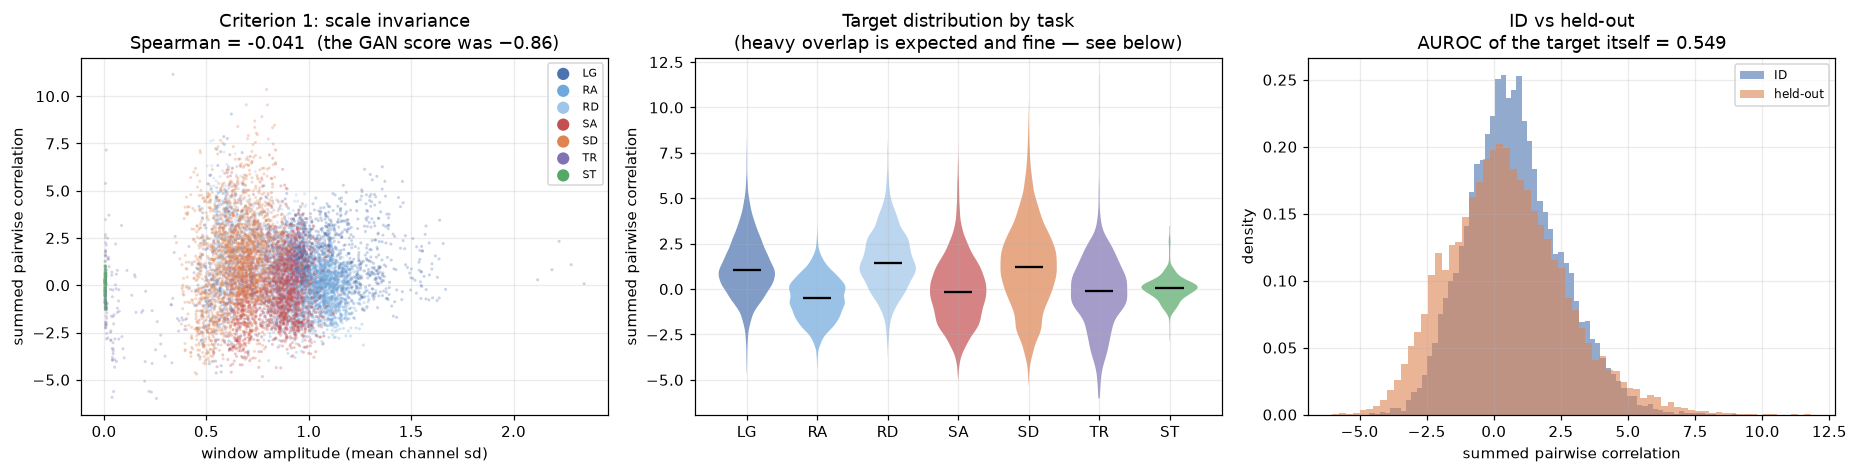

Spearman(target, amplitude) = -0.041
AUROC of the target used directly as a detector = 0.549


In [5]:
tgt_A = summed_pairwise_corr(X)
rho_A = spearmanr(tgt_A, amp)[0]
auc_A = max(roc_auc_score(y, tgt_A), roc_auc_score(y, -tgt_A))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.4))

sub = rng.choice(len(X), 9000, replace=False)
for mo in ORDER:
    s = sub[(meta["mode"].to_numpy()[sub] == mo)]
    if not len(s):
        continue
    axes[0].scatter(amp[s], tgt_A[s], s=4, alpha=0.3, color=MODE_COLS[mo],
                    edgecolors="none", rasterized=True, label=mo)
lg = axes[0].legend(fontsize=7, markerscale=4)
for h in lg.legend_handles:
    h.set_alpha(1)
axes[0].set_xlabel("window amplitude (mean channel sd)")
axes[0].set_ylabel("summed pairwise correlation")
axes[0].set_title(f"Criterion 1: scale invariance\nSpearman = {rho_A:+.3f}  "
                  f"(the GAN score was −0.86)")

order = [m for m in ORDER if (meta["mode"] == m).any()]
for i, mo in enumerate(order):
    s = (meta["mode"] == mo).to_numpy()
    parts = axes[1].violinplot([tgt_A[s]], positions=[i], widths=0.8,
                               showextrema=False, showmedians=True)
    for b in parts["bodies"]:
        b.set_facecolor(MODE_COLS[mo]); b.set_alpha(0.7); b.set_edgecolor("none")
    parts["cmedians"].set_color("black")
axes[1].set_xticks(range(len(order)))
axes[1].set_xticklabels([f"{m}" for m in order])
axes[1].set_ylabel("summed pairwise correlation")
axes[1].set_title("Target distribution by task\n(heavy overlap is expected and fine — see below)")

for lab, col, nm in ((0, C_ID, "ID"), (1, C_OOD, "held-out")):
    axes[2].hist(tgt_A[y == lab], bins=70, density=True, alpha=0.6, color=col, label=nm)
axes[2].set_xlabel("summed pairwise correlation")
axes[2].set_ylabel("density")
axes[2].set_title(f"ID vs held-out\nAUROC of the target itself = {auc_A:.3f}")
axes[2].legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"Spearman(target, amplitude) = {rho_A:+.3f}")
print(f"AUROC of the target used directly as a detector = {auc_A:.3f}")

**Criterion 1: passed, decisively.** Rank correlation with amplitude is −0.03 against the GAN
score's −0.86. The scale invariance is real, not merely nominal.

The third panel needs reading carefully, because a naive reading gets it backwards. The
target's own AUROC of ≈0.55 is *not* a defect. The uncertainty score is the ensemble's variance,
not the target — this model is not supposed to separate classes by predicting a value that
differs between them. A target that separated ID from OOD by itself would be a label in
disguise, and the whole point is that no labels exist out of distribution.

What matters is whether the *task* of predicting this target is hard enough that branches
diverge when the input is unfamiliar. That is criterion 3, and it is where this target is
weakest.

### 1.4 Criterion 3: is the target hard enough to learn?

Ensemble disagreement is driven by target difficulty. Two proxies for how hard this one is:
how much of it a linear model on cheap summary statistics can already explain, and how smooth
it is over time. A target that a linear probe nails is a target seven branches will agree on.

Linear probe on per-channel mean+sd, ID windows only:
  shuffled folds (explainability)          R^2 = +0.519 (+/- 0.015)
  participant-disjoint folds (generalises) R^2 = -1.680 (+/- 1.111)

  The first number is the difficulty measure: how much of the target a linear model on
  first-order statistics already captures. The gap to the second is how participant-
  specific the target is -- a large gap warns that branches may disagree across
  participants rather than across tasks, which would inflate the score on held-out
  subjects for the wrong reason.


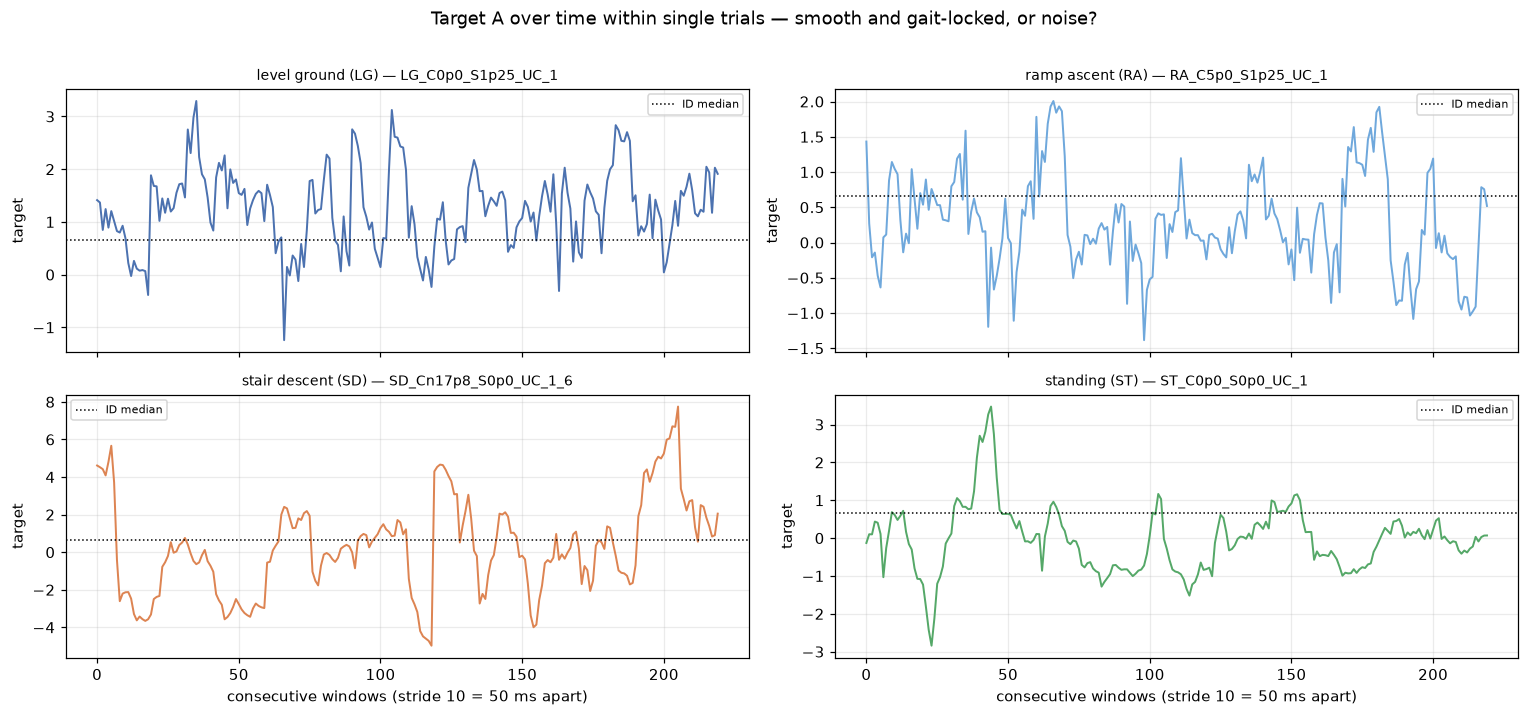

In [6]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold, KFold, cross_val_score

# Cheap summary features: per-channel sd and mean. If a linear model on these explains the
# target, then the "coupling structure" the network is nominally learning is mostly first-order
# information already present in the marginals -- an easy target, and easy targets do not
# produce ensemble disagreement.
#
# Two protocols, because they answer different questions and the folds must be SHUFFLED for the
# first one: the windows arrive ordered by participant, so unshuffled folds measure
# cross-participant generalisation rather than explainability, and report a misleading
# negative R^2.
feat = np.concatenate([X.std(axis=2), X.mean(axis=2)], axis=1)
id_only = y == 0
Xf, tf = feat[id_only], tgt_A[id_only]
groups = meta.loc[id_only, "subject"].to_numpy()

r2_shuf = cross_val_score(Ridge(alpha=1.0), Xf, tf, scoring="r2",
                          cv=KFold(4, shuffle=True, random_state=0))
r2_grp = cross_val_score(Ridge(alpha=1.0), Xf, tf, scoring="r2",
                         cv=GroupKFold(4), groups=groups)

print(f"Linear probe on per-channel mean+sd, ID windows only:")
print(f"  shuffled folds (explainability)          R^2 = {r2_shuf.mean():+.3f} "
      f"(+/- {r2_shuf.std():.3f})")
print(f"  participant-disjoint folds (generalises) R^2 = {r2_grp.mean():+.3f} "
      f"(+/- {r2_grp.std():.3f})")
print()
print("  The first number is the difficulty measure: how much of the target a linear model on")
print("  first-order statistics already captures. The gap to the second is how participant-")
print("  specific the target is -- a large gap warns that branches may disagree across")
print("  participants rather than across tasks, which would inflate the score on held-out")
print("  subjects for the wrong reason.")

# smoothness: how the target evolves within single trials
fig, axes = plt.subplots(2, 2, figsize=(14, 6.4), sharex=True)
for ax, mo in zip(axes.ravel(), ("LG", "RA", "SD", "ST")):
    s = (meta["mode"] == mo).to_numpy()
    if not s.any():
        ax.set_visible(False)
        continue
    trial = meta[s]["trial"].value_counts().idxmax()
    sel = np.flatnonzero(s & (meta["trial"] == trial).to_numpy())[:220]
    ax.plot(np.arange(len(sel)), tgt_A[sel], lw=1.3, color=MODE_COLS[mo])
    ax.axhline(np.median(tgt_A[y == 0]), color="k", ls=":", lw=1, label="ID median")
    ax.set_title(f"{MODE_NAMES[mo]} ({mo}) — {trial}", fontsize=9)
    ax.set_ylabel("target")
    ax.legend(fontsize=7)
for ax in axes[1]:
    ax.set_xlabel("consecutive windows (stride 10 = 50 ms apart)")
fig.suptitle("Target A over time within single trials — smooth and gait-locked, or noise?",
             y=1.01)
fig.tight_layout()
plt.show()

### 1.5 Verdict on target A

Two numbers from the probe above, and the second is the more important.

**Explainability, R² = 0.52.** A linear model on nothing but per-channel means and standard
deviations recovers half of this target. The "cross-channel coupling structure" the network is
nominally being asked to learn is substantially first-order information that is already present
in the marginals. That quantifies criterion 3: the target is easy, and easy targets do not
produce branch disagreement.

**Participant transfer, R² = −1.68.** This was not anticipated and it is a genuine risk to the
experiment. Fit on some participants and tested on others, the probe does far *worse* than
predicting the mean — the target is strongly participant-specific, presumably because summed
correlation depends on each person's IMU mounting and movement style. Our validation and test
splits are participant-disjoint by design, so a large share of whatever branch variance this
ensemble produces on held-out data will be **participant shift rather than task novelty.**

That is a cleaner explanation for the reference work's synthetic-target result (F1 62.5 against
gait phase's 90.3) than target difficulty alone, and it is worth stating because it is testable:
gait phase is participant-invariant by construction, being normalised to 0–100% of the stride,
whereas summed correlation is not normalised to anything.

**Still run it.** Experiment 4 is meant to reproduce the reference work's Table I row, and it
does that faithfully. But add one diagnostic to the evaluation that the other experiments did
not need: **the variance decomposed by participant against by task.** If the between-participant
component dominates, the score is measuring the wrong kind of unfamiliarity, and that is a
reportable result rather than a failure.

---
## Part 2 — Targets B and C: forecasting

Predict the sensor state `h` samples after the window ends. Target B predicts hip angle for
both legs; target C predicts all sixteen channels. They are deliberately identical except in
output width.

### 2.1 No re-windowing is needed

The stored windows are cut at stride 10 from continuous trials, so the row `h/10` positions
later is the same trial advanced by exactly `h` samples, and its final sample is the value we
want. Verified bit-exact below. This means the horizon is a nearly free parameter and no
preprocessing needs rebuilding.

In [7]:
mtr = data.splits["train"].meta
for h in (10, 20, 40):
    rows = forecast_rows(mtr, h)
    print(f"h={h:>3} ({1000*h/200:>3.0f} ms): {(rows >= 0).mean():.4%} of {len(rows):,} "
          f"training windows have a target "
          f"({(rows < 0).sum():,} lost at trial ends)")

# bit-exactness check: window i advanced by h must equal window (i+h/10) at the front
h = 40
rows = forecast_rows(mtr, h)
ok = np.flatnonzero(rows >= 0)[:300]
A = data.splits["train"].tensors(ok).numpy()
B = data.splits["train"].tensors(rows[ok]).numpy()
d = np.abs(A[:, :, h:] - B[:, :, :200 - h]).max()
print(f"\nmax |window_i[{h}:200] - window_partner[0:{200-h}]| = {d:.3e}  "
      f"<- 0 confirms the row join is exact")
print(f"target for row i  ==  X[rows[i], channel, -1]")

h= 10 ( 50 ms): 99.8590% of 187,993 training windows have a target (265 lost at trial ends)
h= 20 (100 ms): 99.7181% of 187,993 training windows have a target (530 lost at trial ends)
h= 40 (200 ms): 99.4361% of 187,993 training windows have a target (1,060 lost at trial ends)

max |window_i[40:200] - window_partner[0:160]| = 0.000e+00  <- 0 confirms the row join is exact
target for row i  ==  X[rows[i], channel, -1]


### 2.2 Criterion 3: the horizon is the whole decision

This is the plot that determines whether targets B and C are worth training at all. For each
horizon, how well do two trivial baselines — persistence (assume no change) and linear
extrapolation from the last two samples — already predict the future value?

`skill` is `1 − RMSE / sd(target)`. Skill of 1 is exact, 0 is no better than guessing the mean,
and negative means the baseline is *worse* than guessing the mean. A horizon where the baseline
skill is near 1 is a horizon where all seven branches learn the same near-exact extrapolator
and the ensemble variance collapses to zero everywhere.

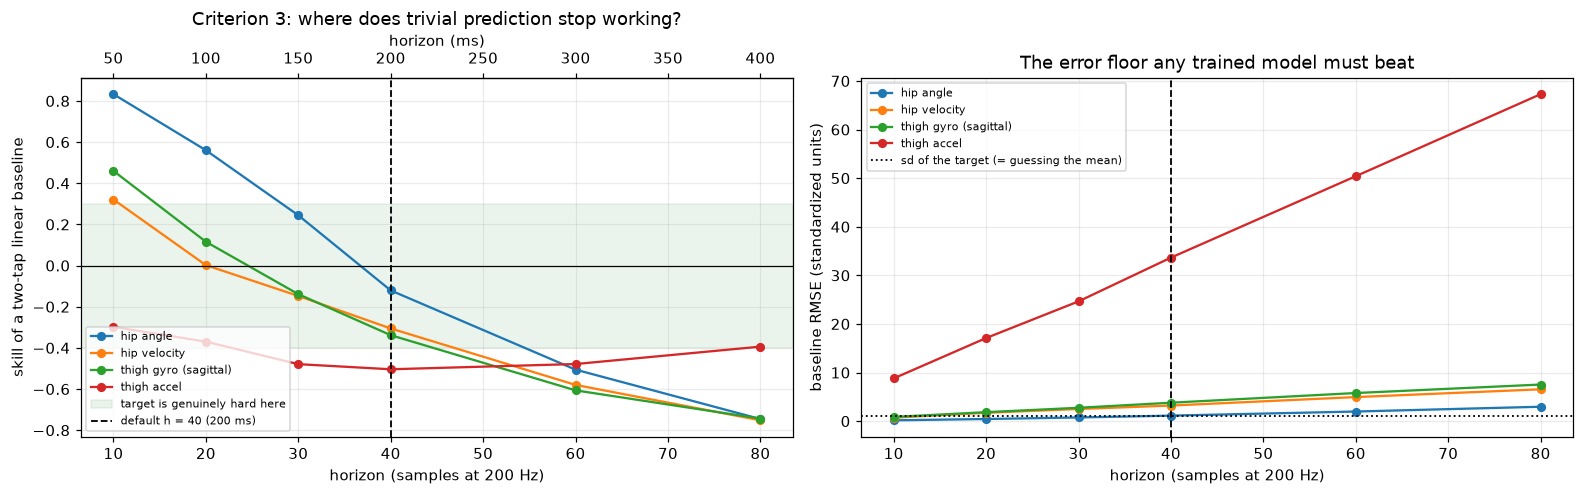

horizon                   10     20     30     40     60     80
group                                                          
hip angle              0.833  0.561  0.244 -0.121 -0.506 -0.746
hip velocity           0.321  0.002 -0.148 -0.306 -0.580 -0.752
thigh accel           -0.298 -0.370 -0.479 -0.504 -0.478 -0.394
thigh gyro (sagittal)  0.460  0.116 -0.139 -0.338 -0.606 -0.744


In [8]:
HORIZONS = [10, 20, 30, 40, 60, 80]
groups = {"hip angle": ["enc_angle_l", "enc_angle_r"],
          "hip velocity": ["enc_velo_l", "enc_velo_r"],
          "thigh gyro (sagittal)": ["thigh_gyro_y_l", "thigh_gyro_y_r"],
          "thigh accel": ["thigh_accel_x_l", "thigh_accel_y_l", "thigh_accel_z_l"]}

rec = []
for name, chans in groups.items():
    for h in HORIZONS:
        sk = np.mean([forecast_skill(X[y == 0], CH.index(c), h)["skill"] for c in chans])
        lin = np.mean([forecast_skill(X[y == 0], CH.index(c), h)["linear_rmse"] for c in chans])
        rec.append({"group": name, "horizon": h, "skill": sk, "linear_rmse": lin})
skill = pd.DataFrame(rec)

fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.6))
for name in groups:
    d = skill[skill["group"] == name]
    axes[0].plot(d["horizon"], d["skill"], "o-", ms=5, label=name)
axes[0].axhspan(-0.4, 0.3, color="#55A868", alpha=0.12,
                label="target is genuinely hard here")
axes[0].axhline(0, color="k", lw=0.8)
axes[0].axvline(DEFAULT_HORIZON, color="k", ls="--", lw=1.2,
                label=f"default h = {DEFAULT_HORIZON} ({1000*DEFAULT_HORIZON/200:.0f} ms)")
axes[0].set_xlabel("horizon (samples at 200 Hz)")
axes[0].set_ylabel("skill of a two-tap linear baseline")
axes[0].set_title("Criterion 3: where does trivial prediction stop working?")
axes[0].legend(fontsize=7, loc="lower left")

sec = axes[0].secondary_xaxis("top", functions=(lambda s: 1000*s/200, lambda m: 200*m/1000))
sec.set_xlabel("horizon (ms)")

for name in groups:
    d = skill[skill["group"] == name]
    axes[1].plot(d["horizon"], d["linear_rmse"], "o-", ms=5, label=name)
axes[1].axhline(1.0, color="k", ls=":", lw=1.2, label="sd of the target (= guessing the mean)")
axes[1].axvline(DEFAULT_HORIZON, color="k", ls="--", lw=1.2)
axes[1].set_xlabel("horizon (samples at 200 Hz)")
axes[1].set_ylabel("baseline RMSE (standardized units)")
axes[1].set_title("The error floor any trained model must beat")
axes[1].legend(fontsize=7)
fig.tight_layout()
plt.show()

print(skill.pivot(index="group", columns="horizon", values="skill").round(3).to_string())

The hip-angle curve is the one to read, because it is target B. At 50 ms a two-tap linear
filter already achieves roughly 0.84 skill; at 5 ms — the "next time step" framing — it is
0.99. Those horizons are unusable: there is nothing left for seven independently initialised
branches to disagree about.

Skill crosses zero near 40 samples (200 ms) and goes negative beyond, meaning the naive
baselines have stopped working and temporal structure must genuinely be learned. That is the
same difficulty class as gait phase, which is why `DEFAULT_HORIZON = 40`.

The high-frequency channels are harder at every horizon, which is the first substantive
argument for target C over target B: predicting sixteen channels including accelerometers and
gyros is a harder problem than predicting two smooth encoder signals, and harder targets
produce more disagreement.

### 2.3 The trap: prediction error is reconstruction error in disguise

A warning that applies to the *score*, not the target. It is tempting to use the realised
prediction error as the anomaly score — that is the natural reading of "the anomaly score
becomes the MSE vector across all sensors". Measure what that would give.

The autoencoder's reconstruction error scored AUROC 0.312 — below chance, anti-correlated with
novelty — because standing is the easiest task to *reconstruct*. Standing is also the easiest
task to *predict*.

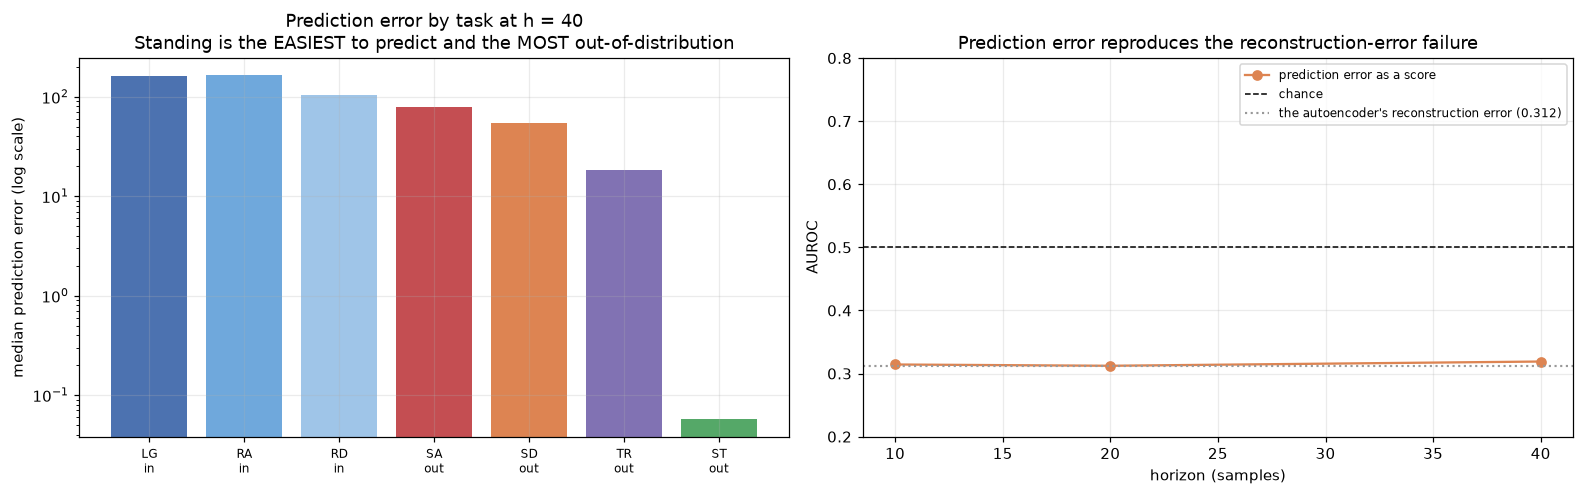

 horizon  auroc  spearman_amp         LG         RA         RD        SA     SD     TR    ST
      10  0.314         0.493  11.427000  11.444000   7.332000  5.151000  3.821  1.261 0.004
      20  0.312         0.499  42.478001  43.467999  27.750999 19.909000 14.094  4.877 0.015
      40  0.319         0.498 161.544006 164.320007 105.150002 78.001999 54.750 18.204 0.057


In [9]:
rows_pred = []
for h in (10, 20, 40):
    t0 = 200 - 1 - h
    cur, prev, true = X[:, :, t0], X[:, :, t0 - 1], X[:, :, -1]
    err = ((true - (cur + h * (cur - prev))) ** 2).mean(axis=1)
    rows_pred.append({"horizon": h, "auroc": roc_auc_score(y, err),
                      "spearman_amp": spearmanr(err, amp)[0],
                      **{m: np.median(err[(meta["mode"] == m).to_numpy()])
                         for m in ORDER if (meta["mode"] == m).any()}})
pred = pd.DataFrame(rows_pred)

fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.6))
h = 40
t0 = 200 - 1 - h
err = ((X[:, :, -1] - (X[:, :, t0] + h * (X[:, :, t0] - X[:, :, t0 - 1]))) ** 2).mean(axis=1)
o = [m for m in ORDER if (meta["mode"] == m).any()]
med = [np.median(err[(meta["mode"] == m).to_numpy()]) for m in o]
axes[0].bar(range(len(o)), med, color=[MODE_COLS[m] for m in o])
axes[0].set_yscale("log")
axes[0].set_xticks(range(len(o)))
axes[0].set_xticklabels([f"{m}\n{'out' if m in ('SA','SD','TR','ST') else 'in'}" for m in o],
                        fontsize=8)
axes[0].set_ylabel("median prediction error (log scale)")
axes[0].set_title(f"Prediction error by task at h = {h}\n"
                  "Standing is the EASIEST to predict and the MOST out-of-distribution")

axes[1].plot(pred["horizon"], pred["auroc"], "o-", ms=6, color=C_OOD,
             label="prediction error as a score")
axes[1].axhline(0.5, color="k", ls="--", lw=1, label="chance")
axes[1].axhline(0.312, color="#999999", ls=":", lw=1.4,
                label="the autoencoder's reconstruction error (0.312)")
axes[1].set_ylim(0.2, 0.8)
axes[1].set_xlabel("horizon (samples)")
axes[1].set_ylabel("AUROC")
axes[1].set_title("Prediction error reproduces the reconstruction-error failure")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

print(pred.round(3).to_string(index=False))

AUROC of 0.31 at every horizon, against the autoencoder's 0.312, with the same task ordering:
standing easiest, ramp ascent hardest. It is the same failure, reached by a different route, and
it is now the third time this dataset has produced it (GAN score, reconstruction error,
prediction error).

A trained model would have lower error everywhere, but the *ordering* is structural: standing is
near-constant, so any forecaster nails it. Prediction error ranks windows by signal complexity,
not by novelty.

**Consequence for the experiment design.** The primary uncertainty score for targets B and C
must remain the branch **variance**, identical in definition to Experiment 1, not the realised
error. The error is worth computing — it is the axis the reference work could not access, and
it is what makes the confidently-wrong case distinguishable from unfamiliar terrain — but it
belongs as a second dimension, and any combination of the two should be screened against this
baseline before being believed.

### 2.4 What the forecast target actually looks like

Sanity check: the joined target should trace the same trajectory as the channel it comes from,
shifted.

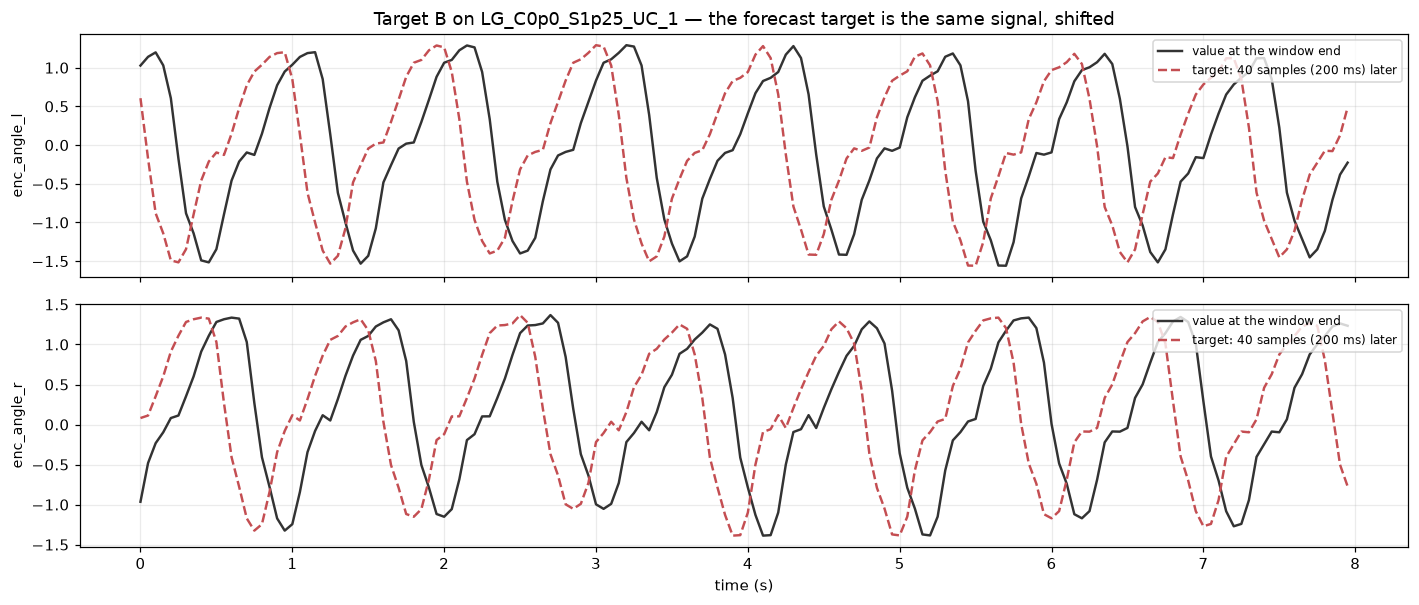

corr(value now, value 40 samples later) = +0.211
A value well below 1 is what we want: it means the target is not simply a copy of the
last input sample, so the network has to extrapolate rather than pass through.


In [10]:
sp = data.splits["test"]
rows = forecast_rows(sp.meta, DEFAULT_HORIZON)
ang = channel_indices(CH, ANGLE_CHANNELS)

trial = sp.meta["trial"].value_counts().idxmax()
sel = np.flatnonzero((sp.meta["trial"] == trial).to_numpy() & (rows >= 0))[:160]
now = sp.tensors(sel).numpy()[:, ang, -1]
fut = sp.tensors(rows[sel]).numpy()[:, ang, -1]

fig, axes = plt.subplots(2, 1, figsize=(13, 5.6), sharex=True)
t = np.arange(len(sel)) * STRIDE / 200
for k, (ax, leg) in enumerate(zip(axes, ANGLE_CHANNELS)):
    ax.plot(t, now[:, k], lw=1.6, color="#333333", label="value at the window end")
    ax.plot(t, fut[:, k], lw=1.6, ls="--", color="#C44E52",
            label=f"target: {DEFAULT_HORIZON} samples "
                  f"({1000*DEFAULT_HORIZON/200:.0f} ms) later")
    ax.set_ylabel(leg, fontsize=9)
    ax.legend(fontsize=8, loc="upper right")
axes[0].set_title(f"Target B on {trial} — the forecast target is the same signal, shifted")
axes[1].set_xlabel("time (s)")
fig.tight_layout()
plt.show()

lag_r = np.corrcoef(now[:, 0], fut[:, 0])[0, 1]
print(f"corr(value now, value {DEFAULT_HORIZON} samples later) = {lag_r:+.3f}")
print("A value well below 1 is what we want: it means the target is not simply a copy of the")
print("last input sample, so the network has to extrapolate rather than pass through.")

---
## Part 3 — Screening summary

All three candidates against the three criteria, plus the two rejected score choices for
context.

In [11]:
def hardness(chans, h):
    return np.mean([forecast_skill(X[y == 0], CH.index(c), h)["skill"] for c in chans])


summary = pd.DataFrame([
    {"candidate": "A: summed pairwise correlation", "outputs": 1,
     "amplitude rho": f"{rho_A:+.3f}", "scale-invariant": "yes",
     "conditioning": f"needs sd floor ({MIN_SD})",
     "difficulty": "low (smooth, local)", "verdict": "run — reproduces Table I"},
    {"candidate": f"B: hip angle, h={DEFAULT_HORIZON}", "outputs": 2,
     "amplitude rho": "n/a", "scale-invariant": "partly",
     "conditioning": "fine",
     "difficulty": f"baseline skill {hardness(ANGLE_CHANNELS, DEFAULT_HORIZON):+.2f}",
     "verdict": "run at h>=40 only"},
    {"candidate": f"C: all 16 channels, h={DEFAULT_HORIZON}", "outputs": 16,
     "amplitude rho": "n/a", "scale-invariant": "partly",
     "conditioning": "fine",
     "difficulty": f"baseline skill {hardness(list(CH), DEFAULT_HORIZON):+.2f}",
     "verdict": "run — hardest target"},
])
print(summary.to_string(index=False))

print("\n\nRejected SCORE choices (not targets) -- for the record:\n")
print(pd.DataFrame([
    {"score": "1 - D(x), GAN discriminator", "AUROC": 0.727,
     "why rejected as novel": "monotone in amplitude (rho -0.86); raw amplitude scores 0.807"},
    {"score": "autoencoder reconstruction error", "AUROC": 0.312,
     "why rejected as novel": "anti-correlated; standing easiest to reconstruct"},
    {"score": "forecast prediction error", "AUROC": round(pred['auroc'].iloc[-1], 3),
     "why rejected as novel": "same failure as reconstruction error, same ordering"},
    {"score": "branch variance (Experiment 1)", "AUROC": 0.859,
     "why rejected as novel": "not rejected -- the only score that has worked"},
]).to_string(index=False))

                     candidate  outputs amplitude rho scale-invariant          conditioning           difficulty                  verdict
A: summed pairwise correlation        1        -0.041             yes needs sd floor (0.01)  low (smooth, local) run — reproduces Table I
            B: hip angle, h=40        2           n/a          partly                  fine baseline skill -0.12        run at h>=40 only
      C: all 16 channels, h=40       16           n/a          partly                  fine baseline skill -0.36     run — hardest target


Rejected SCORE choices (not targets) -- for the record:

                           score  AUROC                                         why rejected as novel
     1 - D(x), GAN discriminator  0.727 monotone in amplitude (rho -0.86); raw amplitude scores 0.807
autoencoder reconstruction error  0.312              anti-correlated; standing easiest to reconstruct
       forecast prediction error  0.319           same failure as reconstruction er

---
## Bottom line

**Run all three, in this order.**

1. **Target A** first. No free parameters, reproduces the reference work's Table I row, and it
   is the safe completion of the four-architecture comparison. Apply the standard-deviation
   floor of 0.01 — without it standing's target is a coin flip. Two expectations, both now
   measured rather than assumed: it will underperform the gait-phase ensemble because half the
   target is recoverable from first-order statistics (R² = 0.52), and its branch variance may
   be contaminated by participant shift rather than task novelty (participant-disjoint
   R² = −1.68). Evaluate it with the variance decomposed by participant against by task.

2. **Targets B and C** at **h = 40 (200 ms)**, differing only in output width. Anything at or
   below 50 ms is wasted compute — a two-tap linear filter reaches 0.83 skill on hip angle
   there, and seven branches will agree everywhere. Target C is the harder problem and the
   better bet: aggregate baseline skill is −0.36 against target B's −0.12, because
   accelerometers are unpredictable even 50 ms out while the encoders are smooth.

   The forecast targets have one structural advantage over target A that the probe result makes
   concrete. A future sensor value is defined identically for every participant, so it does not
   carry the participant-specificity that summed correlation does. Whether that survives
   training is unmeasured, but it is a reason to expect B and C to behave better than A on
   held-out subjects, not merely differently.

**Score everything with branch variance**, identical in definition to Experiment 1, so all six
models sit on one comparison table under one threshold rule. Realised prediction error is
recorded alongside for targets B and C — it is the axis gait phase could never provide, and it
makes "confidently wrong" separable from "unfamiliar terrain" — but Part 2.3 shows it is
worthless as a standalone detector, scoring 0.32 exactly as the autoencoder's reconstruction
error scored 0.312.

**The one thing still unmeasured.** Everything here is computed from baselines, target
statistics and linear probes, not from trained branches. None of it establishes the quantity
that actually decides these experiments: how much seven *trained* branches disagree on
out-of-distribution input, per target. That is what the horizon pilot is for — two branches, a
few epochs, three horizons — and it costs minutes against the roughly twenty-four hours the
three full protocols will take.